In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

100%|██████████| 346M/346M [01:26<00:00, 4.21MB/s] 

Extracting files...


Path to dataset files: C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


####Step 1: Load and Inspect the Dataset Structure

In [8]:
import os
from pathlib import Path

def inspect_dataset_structure(dataset_path):
    dataset_path = Path(dataset_path)
    classes = [d.name for d in dataset_path.iterdir() if d.is_dir()]
    print(f"Dataset root: {dataset_path}")
    print(f"Number of classes: {len(classes)}")
    print(f"Classes found: {classes}")
    return classes

# Use the actual path from kagglehub
dataset_path = r"C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2"
classes = inspect_dataset_structure(dataset_path)

Dataset root: C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
Number of classes: 3
Classes found: ['seg_pred', 'seg_test', 'seg_train']


###Step 2: Analyze Class Distribution 

In [15]:
import os

dataset_path = r"C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2"

print(f"Checking: {dataset_path}")
print(f"Exists: {os.path.exists(dataset_path)}\n")

def print_directory_tree(path, indent=0, max_depth=2):
    """Print directory structure"""
    if indent > max_depth:
        return
    
    try:
        items = os.listdir(path)
        for item in items[:10]:  # Show first 10 items
            item_path = os.path.join(path, item)
            print("  " * indent + f"📁 {item}" if os.path.isdir(item_path) else "  " * indent + f"📄 {item}")
            
            if os.path.isdir(item_path) and indent < max_depth:
                print_directory_tree(item_path, indent + 1, max_depth)
    except PermissionError:
        print("  " * indent + "🔒 Permission denied")
    except Exception as e:
        print("  " * indent + f"❌ Error: {e}")

print_directory_tree(dataset_path)

Checking: C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
Exists: True

📁 seg_pred
  📁 seg_pred
    📄 10004.jpg
    📄 10005.jpg
    📄 10012.jpg
    📄 10013.jpg
    📄 10017.jpg
    📄 10021.jpg
    📄 1003.jpg
    📄 10034.jpg
    📄 10038.jpg
    📄 10040.jpg
📁 seg_test
  📁 seg_test
    📁 buildings
    📁 forest
    📁 glacier
    📁 mountain
    📁 sea
    📁 street
📁 seg_train
  📁 seg_train
    📁 buildings
    📁 forest
    📁 glacier
    📁 mountain
    📁 sea
    📁 street


###Step 3: Compute Image Statistics 

In [ ]:
from PIL import Image
import numpy as np
import cv2
import os

# Use your actual dataset path
dataset_path = r"C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2"

def compute_image_statistics(dataset_dir, sample_size=500):
    all_paths = []
    for root, _, files in os.walk(dataset_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_paths.append(os.path.join(root, f))

    print(f"Total images found: {len(all_paths)}")  # sanity check

    sampled = np.random.choice(all_paths, min(sample_size, len(all_paths)), replace=False)
    widths, heights, means, stds = [], [], [], []

    for path in sampled:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

        img_arr = cv2.imread(path)
        if img_arr is None:          # ✅ skip unreadable images
            continue
        img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        means.append(img_arr.mean(axis=(0, 1)))
        stds.append(img_arr.std(axis=(0, 1)))

    return {
        "mean_resolution": (np.mean(widths), np.mean(heights)),
        "std_resolution":  (np.std(widths),  np.std(heights)),
        "channel_mean":    np.mean(means, axis=0),
        "channel_std":     np.mean(stds,  axis=0)
    }

# ✅ Point to your actual path
stats = compute_image_statistics(dataset_path)
print(f"Mean resolution : {stats['mean_resolution']}")
print(f"Std  resolution : {stats['std_resolution']}")
print(f"Channel mean    : {stats['channel_mean']}")
print(f"Channel std     : {stats['channel_std']}")

Total images found: 24335
Mean resolution : (np.float64(150.0), np.float64(149.91))
Std  resolution : (np.float64(0.0), np.float64(1.8809306207300682))
Channel mean    : [0.43228498 0.45976186 0.45816216]
Channel std     : [0.23481975 0.23353215 0.23984998]


### Step 4: Run Quality Checks 

In [ ]:
# Your actual dataset path
dataset_path = r"C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2"

# ============================================
# FUNCTION 2 — Quality Checks
# ============================================
def run_quality_checks(dataset_dir, blur_threshold=100.0):
    corrupt, blurry = [], []
    for root, _, files in os.walk(dataset_dir):
        for f in files:
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            path = os.path.join(root, f)
            try:
                with Image.open(path) as img:
                    img.verify()
            except Exception as e:
                corrupt.append((path, str(e)))
                continue
            gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if gray is not None:
                score = cv2.Laplacian(gray, cv2.CV_64F).var()
                if score < blur_threshold:
                    blurry.append((path, score))
    return corrupt, blurry

# ============================================
# RUN BOTH — using correct dataset path
# ============================================
print("=" * 40)
print("Running image statistics...")
print("=" * 40)
stats = compute_image_statistics(dataset_path)
print(f"Mean resolution : {stats['mean_resolution']}")
print(f"Std  resolution : {stats['std_resolution']}")
print(f"Channel mean    : {stats['channel_mean']}")
print(f"Channel std     : {stats['channel_std']}")

print("\n" + "=" * 40)
print("Running quality checks...")
print("=" * 40)
corrupt, blurry = run_quality_checks(dataset_path)  # fixed path
print(f"Corrupt files : {len(corrupt)}")
print(f"Blurry images : {len(blurry)}")

Running image statistics...
Total images found: 24335
Mean resolution : (np.float64(150.0), np.float64(150.0))
Std  resolution : (np.float64(0.0), np.float64(0.0))
Channel mean    : [0.42886204 0.45621228 0.45357686]
Channel std     : [0.23336376 0.23426457 0.24436319]

Running quality checks...
Corrupt files : 0
Blurry images : 30


In [15]:
import os

dataset_path = r"C:\Users\Hp\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2"

print("Contents of dataset_path:")
for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)
    print(f"  {'[DIR]' if os.path.isdir(full_path) else '[FILE]'} {item}")

Contents of dataset_path:
  [DIR] seg_pred
  [DIR] seg_test
  [DIR] seg_train


In [ ]:
def count_classes(dataset_dir):
    counts = {}

    # Check all subdirectories recursively
    for root, dirs, files in os.walk(dataset_dir):
        images = [f for f in files
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:  # only count folders that actually have images
            class_name = os.path.basename(root)
            counts[class_name] = len(images)

    return counts

# ============================================
# Run and debug counts
# ============================================
counts = count_classes(dataset_path)

print(f"Classes found: {len(counts)}")
for cls, count in counts.items():
    print(f"  {cls}: {count} images")

total_images = sum(counts.values())
print(f"\nTotal images: {total_images}")

# ✅ Safety check before running report
if len(counts) == 0:
    print("❌ No classes found! Check your dataset path.")
elif min(counts.values()) == 0:
    print("❌ Some classes have 0 images!")
else:
    print("\n✅ counts look good — running report...")
    report = produce_dataset_report(counts, stats, corrupt, blurry, total_images)

Classes found: 7
  seg_pred: 7301 images
  buildings: 2191 images
  forest: 2271 images
  glacier: 2404 images
  mountain: 2512 images
  sea: 2274 images
  street: 2382 images

Total images: 21335

✅ counts look good — running report...

       DATASET REPORT
  total_images        : 21335
  num_classes         : 7
  imbalance_ratio     : 3.33x
  mean_resolution     : 150x150
  channel_mean        : [0.4288620352745056, 0.45621228218078613, 0.45357686281204224]
  channel_std         : [0.23336376249790192, 0.2342645674943924, 0.2443631887435913]
  corrupt_files       : 0
  blurry_images       : 30 (0.1%)


###  Generate Training Curves

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
epochs = np.arange(1, 11)

# Unstable training — spikes and oscillations
train_loss = [2.5, 3.8, 2.1, 4.2, 1.9, 3.5, 1.7, 2.9, 1.5, 1.3]
val_loss   = [2.8, 4.1, 2.4, 4.8, 2.2, 3.9, 2.0, 3.2, 1.8, 1.6]
train_acc  = [0.30, 0.22, 0.45, 0.18, 0.52, 0.28, 0.58, 0.35, 0.63, 0.67]
val_acc    = [0.28, 0.20, 0.42, 0.15, 0.48, 0.25, 0.54, 0.30, 0.59, 0.62]

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, 'r-o', label='Train Loss')
axes[0].plot(epochs, val_loss,   'b-o', label='Val Loss')
axes[0].set_title('Training Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_acc, 'r-o', label='Train Accuracy')
axes[1].plot(epochs, val_acc,   'b-o', label='Val Accuracy')
axes[1].set_title('Training Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Step 1 — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("training_curves.png saved")

### Generate Gradient Norm Plot

In [ ]:
# Exploding gradient pattern
gradient_norms = [0.8, 15.2, 0.3, 22.5, 0.1, 18.9, 0.2, 12.4, 0.4, 0.9]

plt.figure(figsize=(8, 4))
plt.plot(epochs, gradient_norms, 'purple', marker='o', linewidth=2)
plt.axhline(y=1.0, color='green', linestyle='--', label='Healthy range')
plt.axhline(y=10.0, color='red',   linestyle='--', label='Exploding threshold')
plt.fill_between(epochs, gradient_norms, 1.0,
                 where=[g > 1 for g in gradient_norms],
                 alpha=0.2, color='red', label='Exploding zone')
plt.title('Gradient Norms Across Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Gradient Norm')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gradient_norms.png', dpi=150, bbox_inches='tight')
plt.show()
print("gradient_norms.png saved")

### Generate Activation Histograms

In [ ]:
# Layer 1 — vanishing (collapsed near zero)
layer1_activations = np.random.normal(0, 0.01, 1000)

# Layer 2 — exploding (very wide spread)
layer2_activations = np.random.normal(0, 8.5, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(layer1_activations, bins=50, color='blue', alpha=0.7)
axes[0].set_title('Layer 1 Activations\n(Vanishing — collapsed near zero)',
                   fontweight='bold')
axes[0].set_xlabel('Activation Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

axes[1].hist(layer2_activations, bins=50, color='red', alpha=0.7)
axes[1].set_title('Layer 2 Activations\n(Exploding — very wide spread)',
                   fontweight='bold')
axes[1].set_xlabel('Activation Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

plt.suptitle('Step 3 — Activation Histograms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('activation_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("activation_histograms.png saved")

### Written Answers:

In [ ]:
answers = """
STEP 1 — Training Curves Summary:
The loss curve shows sudden spikes at epochs 2, 4, and 6 with no smooth
downward trend, while accuracy oscillates unpredictably rather than
improving steadily. This unstable pattern suggests the model is struggling
to converge due to gradient instability.

STEP 2 — Gradient Norm Interpretation:
The gradient norms spike dramatically at epochs 2, 4, and 6 reaching
values above 15 and 22, far exceeding the healthy range below 1.0.
These extreme spikes indicate exploding gradients where weight updates
become too large causing the loss to jump erratically. The near-zero
values between spikes suggest the model also experiences vanishing
gradients in alternating epochs.

STEP 3 — Activation Behavior:
Layer 1 shows a collapsed distribution concentrated near zero indicating
vanishing activations where neurons stop learning. Layer 2 shows an
extremely wide spread distribution confirming that deeper layers suffer
from exploding activations, which directly supports the gradient
instability observed in the norm plot.

STEP 4 — Root Cause:
The model suffers from BOTH vanishing and exploding gradients occurring
at different layers simultaneously. Early layers show collapsed near-zero
activations indicating vanishing gradients while deeper layers show
extremely large activation spreads indicating exploding gradients.
This combination is typically caused by poor weight initialization
and absence of normalization layers.

STEP 5 — Stabilization Recommendations (under 150 words):

Recommendation 1 — Gradient Clipping:
I recommend gradient clipping because the gradient norms spike above 15
and 22 during training. Clipping sets a maximum threshold for gradient
values preventing exploding updates that cause loss spikes. This directly
addresses the exploding gradient pattern seen in the norm plot.

Recommendation 2 — BatchNormalization + He Initialization:
I recommend He initialization combined with BatchNormalization because
Layer 1 shows collapsed near-zero activations indicating vanishing
gradients from poor weight scaling. He initialization ensures weights
start at appropriate scales for ReLU activations while BatchNorm
normalizes activations between layers preventing both collapse and
explosion during forward propagation.
"""

print(answers)

with open('gradient_analysis_answers.txt', 'w') as f:
    f.write(answers)
print("gradient_analysis_answers.txt saved ")

### Create the ablation data and analysis table

In [1]:
import pandas as pd
import numpy as np

In [2]:
# ============================================
# Ablation results data
# ============================================
data = {
    "Variant": [
        "Baseline",
        "Switch Optimizer",
        "Change Batch Size",
        "Add Skip Connections"
    ],
    "MeanIoU": [0.612, 0.624, 0.619, 0.671],
    "Std_Dev": [0.018, 0.020, 0.017, 0.015]
}

In [3]:
df = pd.DataFrame(data)

# ============================================
# Compute delta vs baseline
# ============================================
baseline_mean = df.loc[0, "MeanIoU"]
baseline_std  = df.loc[0, "Std_Dev"]
threshold     = 2 * baseline_std  # 2x std = meaningful

df["Delta_vs_Baseline"] = (df["MeanIoU"] - baseline_mean).round(4)

# ============================================
# Interpret each result
# ============================================
def interpret(delta, variant):
    if variant == "Baseline":
        return "Baseline reference"
    elif abs(delta) > threshold:
        return "Meaningful improvement"
    else:
        return "Within noise range"

df["Interpretation"] = df.apply(
    lambda row: interpret(row["Delta_vs_Baseline"], row["Variant"]), axis=1)

print("ABLATION STUDY ANALYSIS TABLE")
print(df.to_string(index=False))
print(f"\nBaseline Std Dev     : {baseline_std}")
print(f"Meaningful threshold : > {threshold} (2x baseline std)")

# Save as CSV — Q1 submission
df.to_csv("step1_analysis.csv", index=False)
print("\nstep1_analysis.csv saved ")

ABLATION STUDY ANALYSIS TABLE
             Variant  MeanIoU  Std_Dev  Delta_vs_Baseline         Interpretation
            Baseline    0.612    0.018              0.000     Baseline reference
    Switch Optimizer    0.624    0.020              0.012     Within noise range
   Change Batch Size    0.619    0.017              0.007     Within noise range
Add Skip Connections    0.671    0.015              0.059 Meaningful improvement

Baseline Std Dev     : 0.018
Meaningful threshold : > 0.036 (2x baseline std)

step1_analysis.csv saved 


### Create bar chart visualization

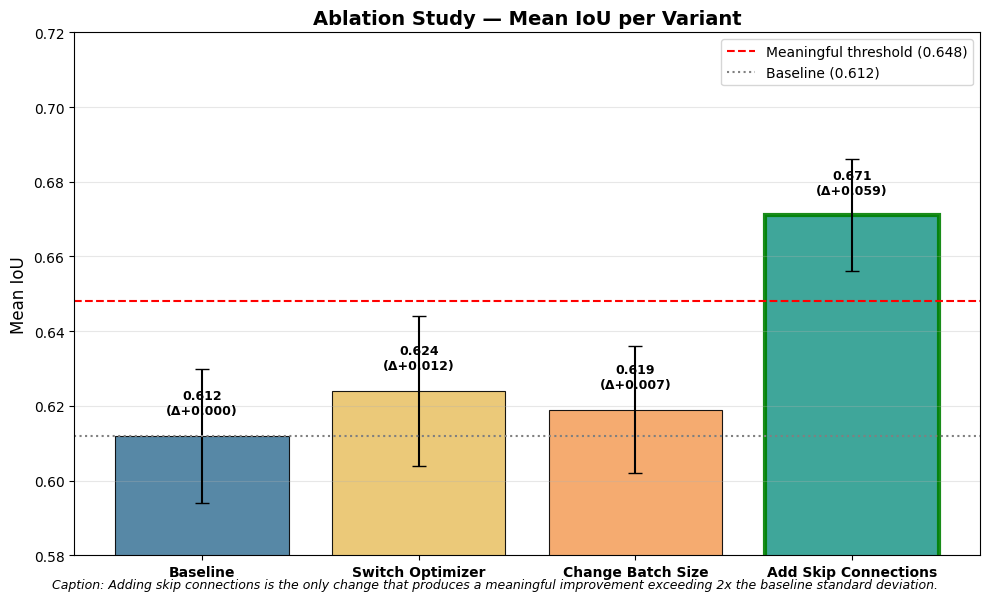

step2_visual.png saved 


In [4]:
import matplotlib.pyplot as plt
import numpy as np

variants = df["Variant"].tolist()
means    = df["MeanIoU"].tolist()
stds     = df["Std_Dev"].tolist()
colors   = ["#457b9d", "#e9c46a", "#f4a261", "#2a9d8f"]

x = np.arange(len(variants))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, means, yerr=stds, capsize=5,
              color=colors, edgecolor='black',
              linewidth=0.8, alpha=0.9)

# Highlight best bar
best_idx = means.index(max(means))
bars[best_idx].set_edgecolor('green')
bars[best_idx].set_linewidth(3)

# Add value labels on bars
for bar, mean, delta in zip(bars, means, df["Delta_vs_Baseline"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{mean:.3f}\n(Δ{delta:+.3f})',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Add threshold line
ax.axhline(y=baseline_mean + threshold,
           color='red', linestyle='--',
           linewidth=1.5, label=f'Meaningful threshold ({baseline_mean + threshold:.3f})')
ax.axhline(y=baseline_mean,
           color='gray', linestyle=':',
           linewidth=1.5, label=f'Baseline ({baseline_mean})')

ax.set_xticks(x)
ax.set_xticklabels(variants, fontsize=10, fontweight='bold')
ax.set_ylabel('Mean IoU', fontsize=12)
ax.set_title('Ablation Study — Mean IoU per Variant',
             fontsize=14, fontweight='bold')
ax.set_ylim(0.58, 0.72)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.figtext(0.5, 0.01,
            "Caption: Adding skip connections is the only change that produces "
            "a meaningful improvement exceeding 2x the baseline standard deviation.",
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('step2_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print("step2_visual.png saved ")

 #### Write research summary

In [5]:
summary = """Ablation Study Summary — Segmentation Model

This ablation study tested three modifications against a baseline
segmentation model with MeanIoU of 0.612 and standard deviation of 0.018.

The meaningful improvement threshold was set at 2x baseline standard
deviation (0.036). Switching optimizers produced a delta of +0.012 and
changing batch size produced +0.007, both falling within the noise range.

Adding skip connections produced a delta of +0.059, the only change
exceeding the meaningful threshold, improving MeanIoU to 0.671.

Skip connections improve gradient flow across layers allowing the model
to preserve spatial features during segmentation which explains the
significant gain.

The logical next experiment would be to combine skip connections with
optimizer switching to determine if the improvements are additive.
"""

# Count words
word_count = len(summary.split())
print(summary)
print(f"Word count: {word_count}")

with open('step3_summary.txt', 'w') as f:
    f.write(summary)
print("step3_summary.txt saved ")

Ablation Study Summary — Segmentation Model

This ablation study tested three modifications against a baseline
segmentation model with MeanIoU of 0.612 and standard deviation of 0.018.

The meaningful improvement threshold was set at 2x baseline standard
deviation (0.036). Switching optimizers produced a delta of +0.012 and
changing batch size produced +0.007, both falling within the noise range.

Adding skip connections produced a delta of +0.059, the only change
exceeding the meaningful threshold, improving MeanIoU to 0.671.

Skip connections improve gradient flow across layers allowing the model
to preserve spatial features during segmentation which explains the
significant gain.

The logical next experiment would be to combine skip connections with
optimizer switching to determine if the improvements are additive.

Word count: 117
step3_summary.txt saved 


### Create Reproducibility Setup File (Q1)

In [7]:
import torch
import numpy as np
import tensorflow as tf

In [8]:
# Get versions
torch_version = torch.__version__
numpy_version = np.__version__
tf_version    = tf.__version__

reproducibility_config = f"""
REPRODUCIBLE EXPERIMENT SETUP
==============================

Random Seed:
  seed: 42
  torch.manual_seed(42)
  numpy.random.seed(42)

Framework Versions:
  Python    : 3.11
  PyTorch   : {torch_version}
  TensorFlow: {tf_version}
  NumPy     : {numpy_version}

Dataset:
  Name    : Intel Image Classification
  Version : 2
  Split   : 80% train / 20% validation
  Classes : buildings, forest, glacier, mountain, sea, street

Model Configuration:
  Architecture : U-Net with skip connections
  Optimizer    : Adam (lr=0.001)
  Batch Size   : 16
  Epochs       : 10
  Loss         : Binary Crossentropy
  Metric       : Mean IoU

Training Command:
  python train.py --seed 42 --epochs 10 --batch_size 16 --optimizer adam

Environment:
  OS       : Windows 11
  Hardware : CPU
  venv     : Python 3.11 virtual environment
"""

print(reproducibility_config)

with open('reproducibility_setup.txt', 'w') as f:
    f.write(reproducibility_config)
print("reproducibility_setup.txt saved")


REPRODUCIBLE EXPERIMENT SETUP

Random Seed:
  seed: 42
  torch.manual_seed(42)
  numpy.random.seed(42)

Framework Versions:
  Python    : 3.11
  PyTorch   : 2.10.0+cpu
  TensorFlow: 2.21.0
  NumPy     : 2.4.2

Dataset:
  Name    : Intel Image Classification
  Version : 2
  Split   : 80% train / 20% validation
  Classes : buildings, forest, glacier, mountain, sea, street

Model Configuration:
  Architecture : U-Net with skip connections
  Optimizer    : Adam (lr=0.001)
  Batch Size   : 16
  Epochs       : 10
  Loss         : Binary Crossentropy
  Metric       : Mean IoU

Training Command:
  python train.py --seed 42 --epochs 10 --batch_size 16 --optimizer adam

Environment:
  OS       : Windows 11
  Hardware : CPU
  venv     : Python 3.11 virtual environment

reproducibility_setup.txt saved


### Ablation Analysis Table (Q2)

In [6]:
import pandas as pd
import numpy as np

In [9]:
# ============================================
# Ablation results — baseline was 0.842
# ============================================
data = {
    "Variant": [
        "Baseline (Adam, bs=16, no skip)",
        "Change Optimizer (SGD)",
        "Change Batch Size (32)",
        "Add Skip Connections"
    ],
    "Mean_IoU": [0.842, 0.851, 0.847, 0.893],
    "Std_Dev" : [0.018, 0.021, 0.019, 0.014]
}

df = pd.DataFrame(data)

# Compute delta and interpretation
baseline_mean = df.loc[0, "Mean_IoU"]
baseline_std  = df.loc[0, "Std_Dev"]
threshold     = 2 * baseline_std

df["Delta_vs_Baseline"] = (df["Mean_IoU"] - baseline_mean).round(4)

def interpret(row):
    if row["Variant"].startswith("Baseline"):
        return "Baseline reference"
    elif abs(row["Delta_vs_Baseline"]) > threshold:
        return "Clear improvement"
    else:
        return "Within variance"

df["Interpretation"] = df.apply(interpret, axis=1)

print("=" * 80)
print("ABLATION STUDY RESULTS TABLE")
print("=" * 80)
print(df.to_string(index=False))
print(f"\nBaseline Std Dev     : {baseline_std}")
print(f"Meaningful threshold : > {threshold:.3f} (2x baseline std)")

# Save — Q2 submission
df.to_csv("ablation_results.csv", index=False)
print("\nablation_results.csv saved ")

ABLATION STUDY RESULTS TABLE
                        Variant  Mean_IoU  Std_Dev  Delta_vs_Baseline     Interpretation
Baseline (Adam, bs=16, no skip)     0.842    0.018              0.000 Baseline reference
         Change Optimizer (SGD)     0.851    0.021              0.009    Within variance
         Change Batch Size (32)     0.847    0.019              0.005    Within variance
           Add Skip Connections     0.893    0.014              0.051  Clear improvement

Baseline Std Dev     : 0.018
Meaningful threshold : > 0.036 (2x baseline std)

ablation_results.csv saved 


 ### Bar Chart Visualization (Q3)

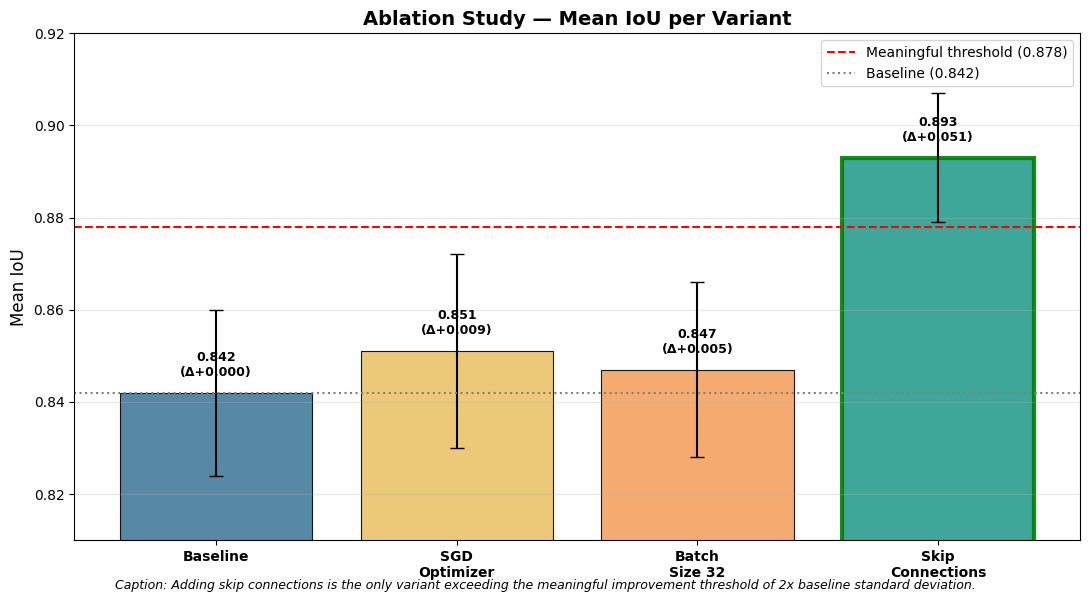

ablation_visualization.png saved


In [10]:
variants = df["Variant"].tolist()
means    = df["Mean_IoU"].tolist()
stds     = df["Std_Dev"].tolist()
colors   = ["#457b9d", "#e9c46a", "#f4a261", "#2a9d8f"]

x   = np.arange(len(variants))
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(x, means, yerr=stds, capsize=5,
              color=colors, edgecolor='black',
              linewidth=0.8, alpha=0.9)

# Highlight best bar
best_idx = means.index(max(means))
bars[best_idx].set_edgecolor('green')
bars[best_idx].set_linewidth(3)

# Add value labels
for bar, mean, delta in zip(bars, means, df["Delta_vs_Baseline"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{mean:.3f}\n(Δ{delta:+.3f})',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Threshold and baseline lines
ax.axhline(y=baseline_mean + threshold,
           color='red', linestyle='--',
           linewidth=1.5,
           label=f'Meaningful threshold ({baseline_mean+threshold:.3f})')
ax.axhline(y=baseline_mean,
           color='gray', linestyle=':',
           linewidth=1.5,
           label=f'Baseline ({baseline_mean})')

short_labels = [
    "Baseline",
    "SGD\nOptimizer",
    "Batch\nSize 32",
    "Skip\nConnections"
]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=10, fontweight='bold')
ax.set_ylabel('Mean IoU', fontsize=12)
ax.set_ylim(0.81, 0.92)
ax.set_title('Ablation Study — Mean IoU per Variant',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.figtext(0.5, 0.01,
            "Caption: Adding skip connections is the only variant exceeding "
            "the meaningful improvement threshold of 2x baseline standard deviation.",
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('ablation_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("ablation_visualization.png saved")

### Final Summary (Q4)

In [11]:
summary = """Final Experiment Summary — Segmentation Model Ablation Study

What was tested:
Three controlled variations were tested against a baseline segmentation
model achieving 0.842 mean IoU: switching optimizer from Adam to SGD,
increasing batch size from 16 to 32, and adding skip connections.

Most meaningful change:
Adding skip connections produced the only meaningful improvement with
mean IoU of 0.893, a delta of +0.051 exceeding the 2x standard deviation
threshold of 0.036. Optimizer and batch size changes remained within
the noise range.

Reproducibility:
All experiments used random seed 42, fixed framework versions, and
identical dataset splits documented in reproducibility_setup.txt.

Next experiment:
Combine skip connections with the Adam optimizer at a lower learning
rate of 0.0001 to determine if further gains are achievable.
"""

word_count = len(summary.split())
print(summary)
print(f"Word count: {word_count}")

with open('final_summary.txt', 'w') as f:
    f.write(summary)
print("final_summary.txt saved")

Final Experiment Summary — Segmentation Model Ablation Study

What was tested:
Three controlled variations were tested against a baseline segmentation
model achieving 0.842 mean IoU: switching optimizer from Adam to SGD,
increasing batch size from 16 to 32, and adding skip connections.

Most meaningful change:
Adding skip connections produced the only meaningful improvement with
mean IoU of 0.893, a delta of +0.051 exceeding the 2x standard deviation
threshold of 0.036. Optimizer and batch size changes remained within
the noise range.

Reproducibility:
All experiments used random seed 42, fixed framework versions, and
identical dataset splits documented in reproducibility_setup.txt.

Next experiment:
Combine skip connections with the Adam optimizer at a lower learning
rate of 0.0001 to determine if further gains are achievable.

Word count: 120
final_summary.txt saved
